In [1]:
#!/usr/bin/env python3
# ================================================================
# summary_potential.py
# Accuracy & Speed Summary for Polyhedron Gravity Potential
# ================================================================

import os, re, math
import numpy as np
from decimal import Decimal, getcontext

# --- Setup paths ---
try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(ROOT, "data")
os.makedirs(DATA, exist_ok=True)

getcontext().prec = 100
SUP_MINUS = "⁻"

# ------------------------------------------------------------
# Formatting helpers
# ------------------------------------------------------------
def format_sci(x, decimals=2):
    """Format value in scientific notation using superscript minus."""
    if not math.isfinite(x) or x == 0.0:
        return f"{'00.' + '0'*decimals}×10{SUP_MINUS}0"
    exp = int(math.floor(math.log10(abs(x))))
    mant = x / (10 ** exp)
    fmt = f"{{:0{2 + 1 + decimals}.{decimals}f}}"
    return f"{fmt.format(mant)}×10{SUP_MINUS}{abs(exp)}"

def read_time(path):
    """Read runtime in seconds from text file."""
    if not os.path.exists(path):
        return np.nan
    with open(path) as f:
        s = f.read()
    m = re.search(r'([0-9]*\.?[0-9]+)', s)
    return float(m.group(1)) if m else np.nan

# ------------------------------------------------------------
# Reference loader (1 column)
# ------------------------------------------------------------
def load_ref_dec():
    txt_ref = os.path.join(DATA, "U_ref_bigfloat_250digits.txt")
    csv_ref = os.path.join(DATA, "U_ref_bigfloat_250.csv")
    if os.path.exists(txt_ref):
        ref = []
        with open(txt_ref) as f:
            for line in f:
                s = line.strip()
                if s:
                    ref.append([Decimal(s)])
        return ref
    elif os.path.exists(csv_ref):
        arr = np.loadtxt(csv_ref, delimiter=",")
        if arr.ndim == 1:
            arr = arr.reshape(-1, 1)
        return [[Decimal(str(v))] for v in arr.tolist()]
    else:
        raise FileNotFoundError("Missing BigFloat potential reference.")

U_ref_dec = load_ref_dec()
Nref = len(U_ref_dec)

# ------------------------------------------------------------
# Loaders
# ------------------------------------------------------------
def load_csv_dec(path):
    arr = np.loadtxt(path, delimiter=",")
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return [[Decimal(str(v)) for v in row] for row in arr.tolist()]

def load_txt_dec(path):
    out = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s:
                out.append([Decimal(s)])
    return out

# ------------------------------------------------------------
# Core comparison
# ------------------------------------------------------------
def compute_row(code, ufile, tfile, as_decimal=False):
    """Compute mean and RMS error relative to the BigFloat(250) reference."""
    u_path = os.path.join(DATA, ufile)
    t_path = os.path.join(DATA, tfile)
    if not os.path.exists(u_path):
        return None

    U_dec = load_txt_dec(u_path) if as_decimal else load_csv_dec(u_path)
    n = min(len(U_dec), Nref)
    if n == 0:
        return None

    abs_sum = Decimal(0)
    sq_sum  = Decimal(0)
    comps = 0
    for i in range(n):
        d = (U_ref_dec[i][0] - U_dec[i][0]).copy_abs()
        abs_sum += d
        sq_sum  += d * d
        comps += 1

    mean_abs = abs_sum / Decimal(comps)
    rms_abs  = (sq_sum / Decimal(comps)).sqrt()

    t = read_time(t_path)
    tpp = (t / n) if np.isfinite(t) and n > 0 else np.nan

    return code, tpp, float(mean_abs), float(rms_abs)

# ------------------------------------------------------------
# Compute all comparisons
# ------------------------------------------------------------
rows = [
    compute_row("Python",   "U_python.csv",              "time_python.txt"),
    compute_row("MATLAB",   "U_matlab_parallel.csv",     "time_matlab_parallel.txt"),
    compute_row("Julia_MP", "U_julia_float64_fast.csv",  "time_julia_float64_fast.txt"),
    compute_row("Julia50",  "U_julia_bigfloat_50.csv",   "time_julia_bigfloat_50.txt", as_decimal=True),
]
rows = [r for r in rows if r is not None]

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------
header_title = "=== Gravitational Potential Accuracy & Speed Summary ==="
header_ref   = "Reference: Julia BigFloat (250 digits)"
header_note  = "Julia 50 comparison performed at 52-digit arithmetic precision."

print(header_title)
print(header_ref)
print(header_note)
print("\nCode  runtime (s/pt)  mean(error)   RMS(error)")

for i, (name, tpp, mean, rms) in enumerate(rows):
    print(f"{i:<5}{name:10s} {format_sci(tpp,2):>12}  {format_sci(mean,2):>12}  {format_sci(rms,2):>12}")

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------
out_path = os.path.join(DATA, "summary_potential.txt")
with open(out_path, "w") as f:
    f.write(header_title + "\n" + header_ref + "\n" + header_note + "\n\n")
    f.write("Code  runtime (s/pt)  mean(error)   RMS(error)\n")
    for i, (name, tpp, mean, rms) in enumerate(rows):
        f.write(f"{i:<5}{name:10s} {format_sci(tpp,2):>12}  {format_sci(mean,2):>12}  {format_sci(rms,2):>12}\n")

print(f"\nSaved: {out_path}")


=== Gravitational Potential Accuracy & Speed Summary ===
Reference: Julia BigFloat (250 digits)
Julia 50 comparison performed at 52-digit arithmetic precision.

Code  runtime (s/pt)  mean(error)   RMS(error)
0    Python       02.48×10⁻6   03.21×10⁻15   03.61×10⁻15
1    MATLAB       05.88×10⁻6   04.88×10⁻15   05.80×10⁻15
2    Julia_MP     03.64×10⁻7   03.02×10⁻15   03.42×10⁻15
3    Julia50      01.53×10⁻4   05.56×10⁻50   07.22×10⁻50

Saved: /Volumes/Dunendran/Programs/Banchmark/Polyhedron/data/summary_potential.txt


In [ ]:
#!/usr/bin/env python3
import os, re, math
import numpy as np
from decimal import Decimal, getcontext

# --- robust path setup ---
try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(ROOT, "data")
os.makedirs(DATA, exist_ok=True)

# High-precision arithmetic
getcontext().prec = 100

SUP_MINUS = "⁻"

def format_sci(x, decimals=2):
    if not math.isfinite(x) or x == 0.0:
        return f"{'00.' + '0'*decimals}×10{SUP_MINUS}0"
    exp = int(math.floor(math.log10(abs(x))))
    mant = x / (10 ** exp)
    fmt = f"{{:0{2 + 1 + decimals}.{decimals}f}}"
    return f"{fmt.format(mant)}×10{SUP_MINUS}{abs(exp)}"

def read_time(path):
    if not os.path.exists(path):
        return np.nan
    with open(path) as f:
        s = f.read()
    m = re.search(r'([0-9]*\.?[0-9]+)', s)
    return float(m.group(1)) if m else np.nan

# --- Reference loader ---
def load_ref_dec():
    txt_ref = os.path.join(DATA, "A_ref_bigfloat_250digits.txt")
    csv_ref = os.path.join(DATA, "A_ref_bigfloat.csv")
    if os.path.exists(txt_ref):
        ref = []
        with open(txt_ref) as f:
            for line in f:
                s = line.strip()
                if s:
                    # split into 3 components
                    parts = [Decimal(p) for p in s.replace(",", " ").split()]
                    ref.append(parts)
        return ref
    elif os.path.exists(csv_ref):
        arr = np.loadtxt(csv_ref, delimiter=",")
        return [[Decimal(str(v)) for v in row] for row in arr.tolist()]
    else:
        raise FileNotFoundError("Missing BigFloat acceleration reference.")

A_ref_dec = load_ref_dec()
Nref = len(A_ref_dec)

# --- Loaders ---
def load_csv_dec(path):
    arr = np.loadtxt(path, delimiter=",")
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    return [[Decimal(str(v)) for v in row] for row in arr.tolist()]

def load_txt_dec(path):
    out = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s:
                parts = [Decimal(p) for p in s.replace(",", " ").split()]
                out.append(parts)
    return out

def compute_row(code, ufile, tfile, as_decimal=False):
    u_path = os.path.join(DATA, ufile)
    t_path = os.path.join(DATA, tfile)
    if not os.path.exists(u_path):
        return None

    U_dec = load_txt_dec(u_path) if as_decimal else load_csv_dec(u_path)
    n = min(len(U_dec), Nref)
    if n == 0:
        return None

    abs_sum = Decimal(0)
    sq_sum  = Decimal(0)
    comps = 0
    for i in range(n):
        for j in range(len(A_ref_dec[i])):
            d = (A_ref_dec[i][j] - U_dec[i][j]).copy_abs()
            abs_sum += d
            sq_sum  += d * d
            comps += 1

    mean_abs = abs_sum / Decimal(comps)
    rms_abs  = (sq_sum / Decimal(comps)).sqrt()

    t = read_time(t_path)
    tpp = (t / n) if np.isfinite(t) and n > 0 else np.nan

    return code, tpp, float(mean_abs), float(rms_abs)

# --- Compute ---
rows = [
    compute_row("Python",   "A_python.csv",           "time_accel_python.txt"),
    compute_row("MATLAB",   "A_matlab_parallel.csv",  "time_accel_matlab_parallel.txt"),
    compute_row("Julia_MP", "A_julia_float64_fast.csv", "time_julia_accel_float64_fast.txt"),
    compute_row("Julia50",  "A_julia_bigfloat_50.csv",  "time_julia_accel_bigfloat_50.txt", as_decimal=True),
]
rows = [r for r in rows if r is not None]

# --- Output ---
header_title = "=== Gravitational Acceleration Accuracy & Speed Summary ==="
header_ref   = "Reference: Julia BigFloat (250 digits)"
header_note  = "Julia 50 comparison performed at 52-digit arithmetic precision."

print(header_title)
print(header_ref)
print(header_note)
print("\nCode  runtime (s/pt)  mean(error)   RMS(error)")

for i, (name, tpp, mean, rms) in enumerate(rows):
    print(f"{i:<5}{name:10s} {format_sci(tpp,2):>12}  {format_sci(mean,2):>12}  {format_sci(rms,2):>12}")

out_path = os.path.join(DATA, "summary_acceleration.txt")
with open(out_path, "w") as f:
    f.write(header_title + "\n" + header_ref + "\n" + header_note + "\n\n")
    f.write("Code  runtime (s/pt)  mean(error)   RMS(error)\n")
    for i, (name, tpp, mean, rms) in enumerate(rows):
        f.write(f"{i:<5}{name:10s} {format_sci(tpp,2):>12}  {format_sci(mean,2):>12}  {format_sci(rms,2):>12}\n")

print(f"\nSaved: {out_path}")


In [ ]:
#!/usr/bin/env python3
import os, re, math
import numpy as np
from decimal import Decimal, getcontext

try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(ROOT, "data")
os.makedirs(DATA, exist_ok=True)

getcontext().prec = 100
SUP_MINUS = "⁻"

def format_sci(x, decimals=2):
    if not math.isfinite(x) or x == 0.0:
        return f"{'00.' + '0'*decimals}×10{SUP_MINUS}0"
    exp = int(math.floor(math.log10(abs(x))))
    mant = x / (10 ** exp)
    fmt = f"{{:0{2 + 1 + decimals}.{decimals}f}}"
    return f"{fmt.format(mant)}×10{SUP_MINUS}{abs(exp)}"

def read_time(path):
    if not os.path.exists(path):
        return np.nan
    with open(path) as f:
        s = f.read()
    m = re.search(r'([0-9]*\.?[0-9]+)', s)
    return float(m.group(1)) if m else np.nan

# --- Reference loader (9 columns) ---
def load_ref_dec():
    txt_ref = os.path.join(DATA, "T_ref_bigfloat_250digits.txt")
    csv_ref = os.path.join(DATA, "T_ref_bigfloat.csv")
    if os.path.exists(txt_ref):
        ref = []
        with open(txt_ref) as f:
            for line in f:
                s = line.strip()
                if s:
                    parts = [Decimal(p) for p in s.replace(",", " ").split()]
                    ref.append(parts)
        return ref
    elif os.path.exists(csv_ref):
        arr = np.loadtxt(csv_ref, delimiter=",")
        return [[Decimal(str(v)) for v in row] for row in arr.tolist()]
    else:
        raise FileNotFoundError("Missing BigFloat tensor reference.")

T_ref_dec = load_ref_dec()
Nref = len(T_ref_dec)

def load_csv_dec(path):
    arr = np.loadtxt(path, delimiter=",")
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    return [[Decimal(str(v)) for v in row] for row in arr.tolist()]

def load_txt_dec(path):
    out = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s:
                parts = [Decimal(p) for p in s.replace(",", " ").split()]
                out.append(parts)
    return out

def compute_row(code, ufile, tfile, as_decimal=False):
    u_path = os.path.join(DATA, ufile)
    t_path = os.path.join(DATA, tfile)
    if not os.path.exists(u_path):
        return None

    U_dec = load_txt_dec(u_path) if as_decimal else load_csv_dec(u_path)
    n = min(len(U_dec), Nref)
    if n == 0:
        return None

    abs_sum = Decimal(0)
    sq_sum  = Decimal(0)
    comps = 0
    for i in range(n):
        for j in range(len(T_ref_dec[i])):
            d = (T_ref_dec[i][j] - U_dec[i][j]).copy_abs()
            abs_sum += d
            sq_sum  += d * d
            comps += 1

    mean_abs = abs_sum / Decimal(comps)
    rms_abs  = (sq_sum / Decimal(comps)).sqrt()

    t = read_time(t_path)
    tpp = (t / n) if np.isfinite(t) and n > 0 else np.nan

    return code, tpp, float(mean_abs), float(rms_abs)

# --- Compute ---
rows = [
    compute_row("Python",   "T_python.csv",           "time_tensor_python.txt"),
    compute_row("MATLAB",   "T_matlab_parallel.csv",  "time_tensor_matlab_parallel.txt"),
    compute_row("Julia_MP", "T_julia_float64_fast.csv", "time_julia_tensor_float64_fast.txt"),
    compute_row("Julia50",  "T_julia_bigfloat_50.csv",  "time_julia_tensor_bigfloat_50.txt", as_decimal=True),
]
rows = [r for r in rows if r is not None]

# --- Output ---
header_title = "=== Gravity Gradient Tensor Accuracy & Speed Summary ==="
header_ref   = "Reference: Julia BigFloat (250 digits)"
header_note  = "Julia 50 comparison performed at 52-digit arithmetic precision."

print(header_title)
print(header_ref)
print(header_note)
print("\nCode  runtime (s/pt)  mean(error)   RMS(error)")

for i, (name, tpp, mean, rms) in enumerate(rows):
    print(f"{i:<5}{name:10s} {format_sci(tpp,2):>12}  {format_sci(mean,2):>12}  {format_sci(rms,2):>12}")

out_path = os.path.join(DATA, "summary_tensor.txt")
with open(out_path, "w") as f:
    f.write(header_title + "\n" + header_ref + "\n" + header_note + "\n\n")
    f.write("Code  runtime (s/pt)  mean(error)   RMS(error)\n")
    for i, (name, tpp, mean, rms) in enumerate(rows):
        f.write(f"{i:<5}{name:10s} {format_sci(tpp,2):>12}  {format_sci(mean,2):>12}  {format_sci(rms,2):>12}\n")

print(f"\nSaved: {out_path}")


In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# ------------------ File Paths ------------------
import os

try:
    # Works when run as a normal script
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    # Fallback for interactive environments (Jupyter/IPython)
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(ROOT, "data")
csv_path = os.path.join(DATA, "precision_scaling.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing data file: {csv_path}")


In [ ]:
# ------------------ Load CSV ------------------
df = pd.read_csv(csv_path)
df = df.sort_values("precision_digits")

prec = df["precision_digits"].to_numpy()
time_per_pt = df["time_per_pt_sec"].to_numpy()
rms_err = df["rms_error"].to_numpy()

# ------------------ Plot: log-log ------------------
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.plot(prec, time_per_pt, "o-", color="tab:blue", label="Runtime per point")
ax1.set_xlabel("Precision (digits)", fontsize=12)
ax1.set_ylabel("Time per point (s)", color="tab:blue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(True, which="both", ls="--", alpha=0.3)

# Twin axis for RMS error
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.plot(prec, rms_err, "s--", color="tab:red", label="RMS Error (vs 250-digit ref)")
ax2.set_ylabel("RMS Error", color="tab:red", fontsize=12)
ax2.tick_params(axis='y', labelcolor="tab:red")

# Title and legend
plt.title("Polyhedron Gravity: Precision vs Runtime", fontsize=13)
ax1.legend(loc="upper left")
ax2.legend(loc="lower right")

# Save plot
out_path = os.path.join(DATA, "precision_scaling_py.png")
plt.tight_layout()
plt.savefig(out_path, dpi=300)
plt.close()

print(f"Saved: {out_path}")


In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------ File Paths ------------------
try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(ROOT, "data")
csv_path = os.path.join(DATA, "precision_scaling.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing data file: {csv_path}")

# ------------------ Load CSV ------------------
df = pd.read_csv(csv_path)
df = df.sort_values("precision_digits")

prec = df["precision_digits"].to_numpy()
time_per_pt = df["time_per_pt_sec"].to_numpy()
rms_err = df["rms_error"].to_numpy()

# ------------------ Plot: Semi-log line plot ------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "lines.linewidth": 2
})

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.set_yscale("log")

# Left axis: runtime
ax1.plot(prec, time_per_pt, color="tab:blue", label="Runtime per point")
ax1.set_xlabel("Precision (digits)", fontsize=12)
ax1.set_ylabel("Time per point (s)", color="tab:blue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(True, which="both", ls="--", alpha=0.3)

# Right axis: RMS error
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.plot(prec, rms_err, color="tab:red", linestyle="--", label="RMS Error (vs 250-digit ref)")
ax2.set_ylabel("RMS Error", color="tab:red", fontsize=12)
ax2.tick_params(axis='y', labelcolor="tab:red")

# Title & legends
plt.title("Polyhedron Gravity: Precision vs Runtime (Semi-Log Line Plot)", fontsize=13)
ax1.legend(loc="upper left")
ax2.legend(loc="lower right")

# Save & close
out_path = os.path.join(DATA, "precision_scaling_lines.png")
plt.tight_layout()
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")


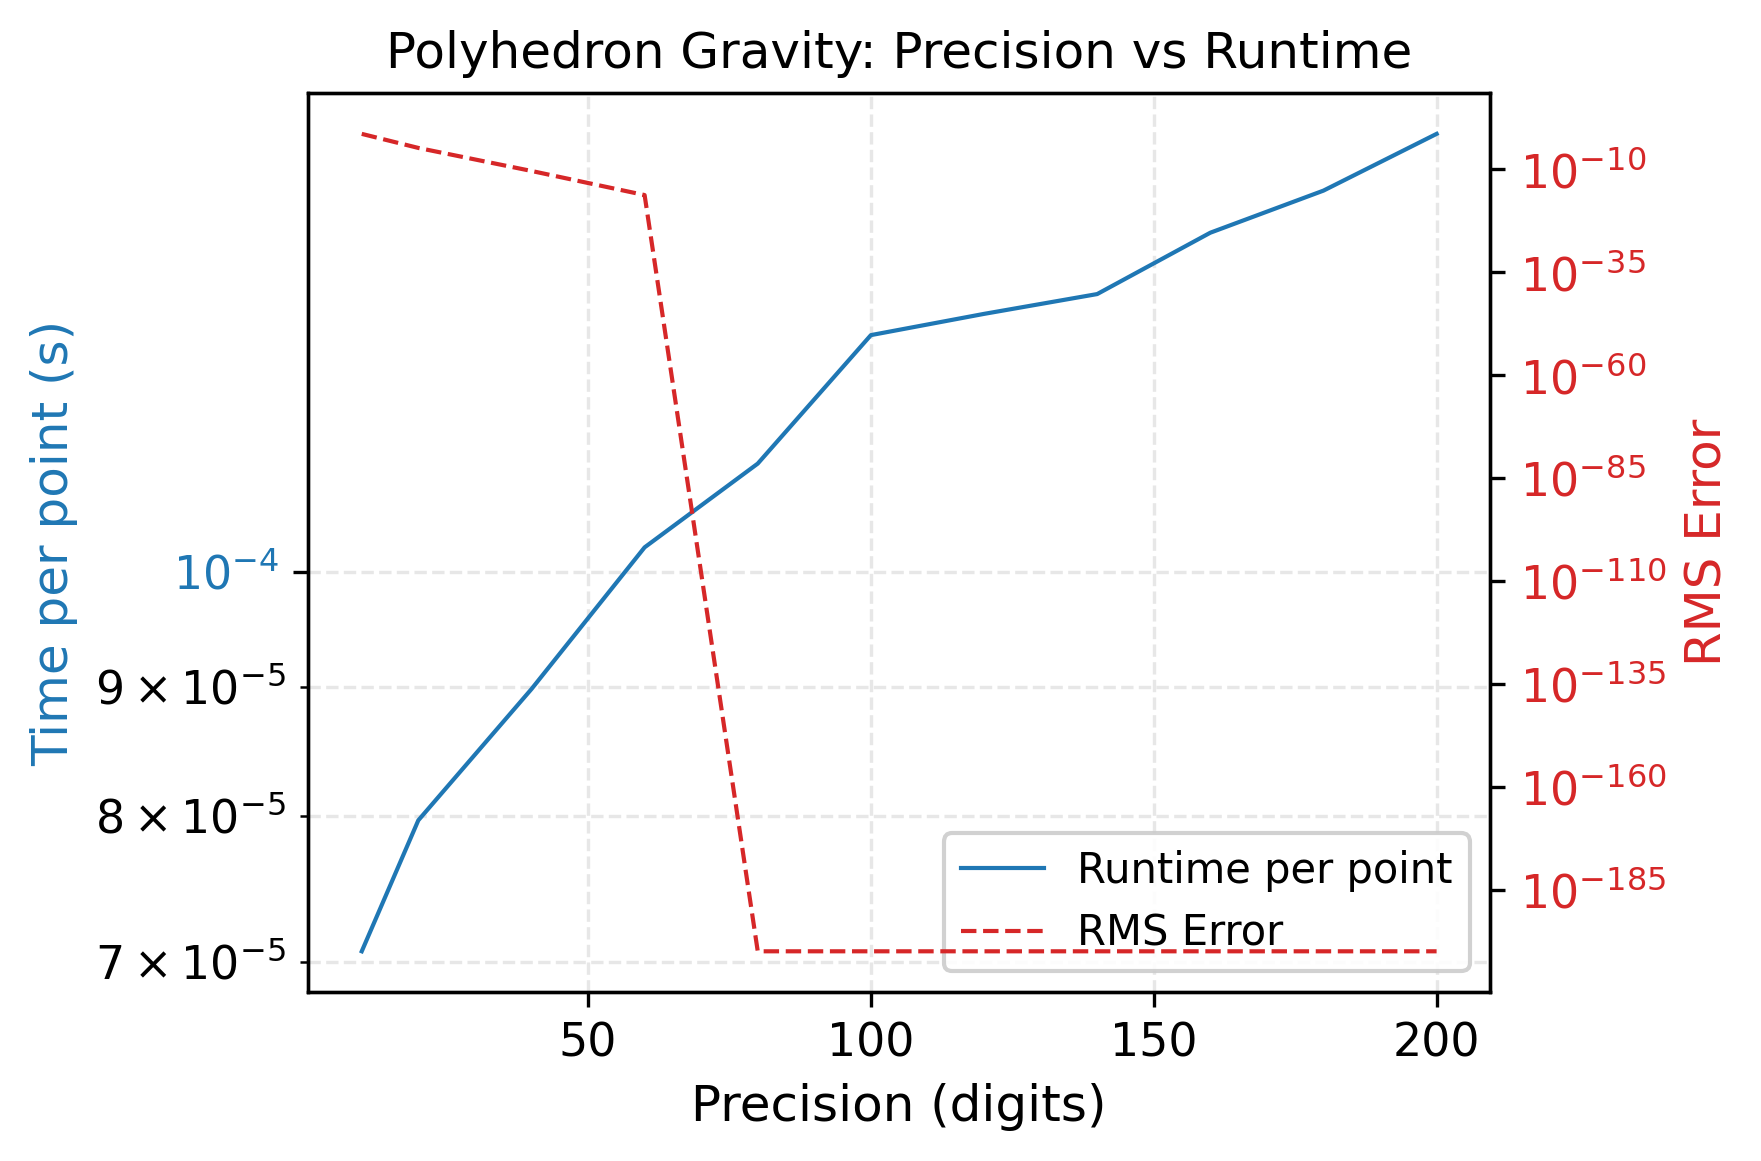

Saved: /Volumes/Dunendran/Programs/Banchmark/Polyhedron/data/precision_scaling_highprec_unifiedlegend.png


In [1]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal, getcontext

# ------------------ Settings ------------------
getcontext().prec = 100  # retain ~100-digit significance for RMS calc

try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA = os.path.join(ROOT, "data")
csv_path = os.path.join(DATA, "precision_scaling.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing data file: {csv_path}")

# ------------------ Load CSV ------------------
df = pd.read_csv(csv_path)
df = df.sort_values("precision_digits")

prec = df["precision_digits"].to_numpy()
time_per_pt = df["time_per_pt_sec"].to_numpy()
rms_err_raw = df["rms_error"].astype(str).tolist()  # keep high precision

# ------------------ Convert RMS with high precision ------------------
rms_err = []
for val in rms_err_raw:
    try:
        d = Decimal(val)
        if d == 0:
            d = Decimal("1e-200")  # avoid zeros for log scale
        rms_err.append(float(d))
    except Exception:
        rms_err.append(np.nan)

# ------------------ Plot: semi-log line plot with unified legend ------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "lines.linewidth": 1
})

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.set_yscale("log")

# Left Y-axis: runtime
line1, = ax1.plot(prec, time_per_pt, color="tab:blue", label="Runtime per point")
ax1.set_xlabel("Precision (digits)", fontsize=12)
ax1.set_ylabel("Time per point (s)", color="tab:blue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(True, which="both", ls="--", alpha=0.3)

# Right Y-axis: RMS error
ax2 = ax1.twinx()
ax2.set_yscale("log")
line2, = ax2.plot(prec, rms_err, color="tab:red", linestyle="--", label="RMS Error")
ax2.set_ylabel("RMS Error", color="tab:red", fontsize=12)
ax2.tick_params(axis='y', labelcolor="tab:red")

# ------------------ Unified Legend ------------------
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="lower right", frameon=True, facecolor="white", framealpha=0.9)

# ------------------ Title & Save ------------------
plt.title("Polyhedron Gravity: Precision vs Runtime", fontsize=12)
out_path = os.path.join(DATA, "precision_scaling_highprec_unifiedlegend.png")
plt.tight_layout()
plt.savefig(out_path, dpi=300)
plt.show()

print(f"Saved: {out_path}")
